In [ ]:
# ============================================================
# 1. PROJECT OVERVIEW: BLUR VS SHARP CLASSIFICATION
# ============================================================
# This project focuses on classifying images as blurry or sharp
# using a dual-branch architecture combining:
#   - Spatial features (Branch A)
#   - Frequency domain features (Branch B)
#
# Key contributions:
# 1. Multi-scale spatial feature extraction (3x3, 5x5, 7x7 grids)
# 2. Dual-branch fusion of spatial + frequency features
#
# The system uses handcrafted features + XGBoost classifier
# for efficient and interpretable image classification.
# ============================================================

## 1. Imports & Setup

In [2]:
!pip install opencv-python xgboost scikit-image -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

print("All imports successful!")

All imports successful!


In [8]:
# ============================================================
# 2. PATCH-LEVEL FEATURE EXTRACTION (BRANCH A - CORE FEATURES)
# ============================================================
# In this step, each image is divided into smaller regions
# called "patches".
#
# From each patch, we extract 6 important features:
# - Laplacian Mean       -> Edge strength
# - Laplacian Variance   -> Sharpness (very important)
# - Tenengrad            -> Gradient strength
# - NGLV                 -> Texture variation
# - LBP Mean             -> Texture pattern
# - LBP Variance         -> Texture complexity
#
# These features help differentiate blurry vs sharp regions.
# ============================================================

In [3]:
# --- UNCHANGED ---
def extract_patch_features(patch):
    lap = cv2.Laplacian(patch, cv2.CV_64F)
    lap_mean, lap_var = float(np.mean(lap)), float(np.var(lap))
    sx = cv2.Sobel(patch, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(patch, cv2.CV_64F, 0, 1, ksize=3)
    tenengrad = float(np.mean(sx**2 + sy**2))
    mu = float(np.mean(patch)) + 1e-8
    nglv = float(np.var(patch)) / mu
    lbp = local_binary_pattern(patch, P=8, R=1, method='uniform')
    lbp_mean, lbp_var = float(np.mean(lbp)), float(np.var(lbp))
    return [lap_mean, lap_var, tenengrad, nglv, lbp_mean, lbp_var]
    

# ============================================================
# 3. MULTI-SCALE FEATURE AGGREGATION
# ============================================================
# Instead of keeping features from every patch (which leads
# to variable-length vectors), we aggregate them.
#
# For each feature, we compute:
# - Mean
# - Standard Deviation
# - Maximum
# - Minimum
#
# This ensures:
# - Fixed-length feature vector (24 features per grid)
# - Robust representation of entire image
# ============================================================



# --- NEW: add this ---
def aggregate_patch_features(gray, grid):
    """Extract and aggregate patch features for one grid size -> 24-dim vector."""
    H, W = gray.shape
    ph, pw = H // grid, W // grid
    if ph == 0 or pw == 0:
        return [0.0] * 24

    all_patch_feats = []
    for i in range(grid):
        for j in range(grid):
            patch = gray[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            if patch.size > 0:
                all_patch_feats.append(extract_patch_features(patch))

    if not all_patch_feats:
        return [0.0] * 24

    arr = np.array(all_patch_feats)   # shape: (num_patches, 6)
    agg = np.concatenate([
        arr.mean(axis=0),  # 6-dim
        arr.std(axis=0),   # 6-dim
        arr.max(axis=0),   # 6-dim
        arr.min(axis=0),   # 6-dim
    ])
    return agg.tolist()    # always 24-dim



# ============================================================
# 4. BRANCH A: MULTI-SCALE SPATIAL FEATURES
# ============================================================
# This branch captures spatial information using multiple grids:
#   - 3x3 (coarse)
#   - 5x5 (medium)
#   - 7x7 (fine)
#
# Why multi-scale?
# - 3x3 → global structure
# - 5x5 → regional patterns
# - 7x7 → fine details
#
# Final output:
# - 72 features (24 per grid × 3 grids)
# ============================================================


# --- REPLACED: old branch_a_features is gone, use this instead ---
def branch_a_features(image_path, fixed_grid=None):
    """
    Hierarchical multi-scale spatial features.
    fixed_grid=None  -> all 3 scales (3x3 + 5x5 + 7x7) -> 72-dim
    fixed_grid=7     -> only 7x7 -> 24-dim  (for ablation)
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if fixed_grid is not None:
        # Ablation mode: single fixed grid
        return aggregate_patch_features(gray, fixed_grid)
    else:
        # Multi-scale mode: all three grids
        feats_3 = aggregate_patch_features(gray, 3)
        feats_5 = aggregate_patch_features(gray, 5)
        feats_7 = aggregate_patch_features(gray, 7)
        return feats_3 + feats_5 + feats_7   # 72-dim, always fixed

In [ ]:
# ============================================================
# 5. BRANCH B: FREQUENCY DOMAIN FEATURES (FFT)
# ============================================================
# This branch analyzes the image in the frequency domain.
#
# Steps:
# 1. Apply Hann window (reduce edge artifacts)
# 2. Apply FFT (convert to frequency domain)
# 3. Shift low frequency to center
# 4. Extract magnitude spectrum
# 5. Crop center region (32x32 → 1024 features)
#
# Key idea:
# - Sharp images → strong high-frequency components
# - Blurry images → weak high-frequency components
# ============================================================

In [4]:
def branch_b_features(image_path, patch_size=32):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = img.astype(np.float32)
    H, W = img.shape

    hann_2d = np.outer(np.hanning(H), np.hanning(W))
    windowed = img * hann_2d

    fft_shifted = np.fft.fftshift(np.fft.fft2(windowed))
    magnitude = np.log1p(np.abs(fft_shifted))

    cy, cx = H // 2, W // 2
    half = patch_size // 2
    if cy < half or cx < half:
        magnitude = cv2.resize(magnitude, (patch_size * 2, patch_size * 2))
        cy = cx = patch_size

    patch = magnitude[cy-half:cy+half, cx-half:cx+half]
    pmin, pmax = patch.min(), patch.max()
    patch = (patch - pmin) / (pmax - pmin + 1e-8)
    return patch.flatten().tolist()

print("Branch B defined. Output: 1024-dim Fourier magnitude vector")

Branch B defined. Output: 1024-dim Fourier magnitude vector


In [ ]:
# ============================================================
# 6. DUAL-BRANCH FEATURE FUSION (OUR METHOD)
# ============================================================
# This is the core idea of the project.
#
# We combine:
# - Branch A → Spatial features (texture, edges)
# - Branch B → Frequency features (FFT)
#
# Why fusion?
# - Spatial captures local structure
# - Frequency captures global blur characteristics
#
# Final feature vector:
# - 72 (A) + 1024 (B) = 1096 features
# ============================================================

In [5]:
def extract_dual_branch_features(image_path, fixed_grid=None):
    feat_a = branch_a_features(image_path, fixed_grid=fixed_grid)
    feat_b = branch_b_features(image_path)

    if feat_a is None or feat_b is None:
        return None

    return feat_a + feat_b


# ✅ Updated info (multi-scale aware)
print("Dual-branch fusion defined.\n")

print("Feature dimensions:")
print("  Branch A fixed 7x7  : 24-dim")
print("  Branch A multi-scale: 72-dim  (3x3 + 5x5 + 7x7 aggregated)")
print("  Branch B Fourier    : 1024-dim")
print("  Dual fixed 7x7      : 24 + 1024 = 1048-dim")
print("  Dual multi-scale    : 72 + 1024 = 1096-dim  <- Our method")

Dual-branch fusion defined.

Feature dimensions:
  Branch A fixed 7x7  : 24-dim
  Branch A multi-scale: 72-dim  (3x3 + 5x5 + 7x7 aggregated)
  Branch B Fourier    : 1024-dim
  Dual fixed 7x7      : 24 + 1024 = 1048-dim
  Dual multi-scale    : 72 + 1024 = 1096-dim  <- Our method


## 6. Dataset Loading

Expected structure:

We load **5 configurations** for the ablation study.

In [ ]:
# ============================================================
# 7. DATASET LOADING AND PREPROCESSING
# ============================================================
# Dataset structure:
# dataset/
#   train/
#       blurry/
#       sharp/
#   test/
#       blurry/
#       sharp/
#
# Each image is:
# - Loaded
# - Converted into feature vector
# - Assigned label (0 = blurry, 1 = sharp)
#
# sample_ratio is used to reduce dataset size for faster runs.
# ============================================================

In [14]:
import random

def load_dataset(base_dir, mode="dual", fixed_grid=None, sample_ratio=1.0):
    X, y = [], []
    classes = {"blurry": 0, "sharp": 1}
    img_exts = (".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG")

    for class_name, label in classes.items():
        class_dir = os.path.join(base_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"  Warning: {class_dir} not found.")
            continue

        print(f"\n  Processing class: {class_name}")

        # ✅ Filter valid images FIRST, then sample
        all_files = os.listdir(class_dir)
        valid_files = [f for f in all_files if f.lower().endswith(img_exts)]

        # ✅ Shuffle before sampling to avoid ordering bias
        random.seed(42)
        random.shuffle(valid_files)

        # ✅ Apply sample_ratio
        if sample_ratio < 1.0:
            limit = max(1, int(len(valid_files) * sample_ratio))
            sampled_files = valid_files[:limit]
        else:
            sampled_files = valid_files

        print(f"  Using {len(sampled_files)} / {len(valid_files)} images")

        for i, img_name in enumerate(sampled_files):
            if i % 50 == 0:
                print(f"  {class_name}: {i} / {len(sampled_files)} processed")

            img_path = os.path.join(class_dir, img_name)

            if mode == "dual":
                features = extract_dual_branch_features(img_path, fixed_grid=fixed_grid)
            elif mode == "branch_a":
                features = branch_a_features(img_path, fixed_grid=fixed_grid)
            else:
                features = branch_b_features(img_path)

            if features is not None:
                X.append(features)
                y.append(label)

    if len(X) == 0:
        return np.zeros((0, 1), dtype=np.float32), np.zeros(0)

    return np.array(X, dtype=np.float32), np.array(y)


# ================== MAIN ==================

train_dir = "dataset/train"
test_dir  = "dataset/test"

train_sample_ratio = 0.2   # 20% of train = ~2000 images (change to 1.0 for full run)
test_sample_ratio  = 1.0   # ✅ ALWAYS full test set for reliable evaluation

configs = {
    "Branch A - Fixed 7x7":      ("branch_a", 7),
    "Branch A - Multi-Scale":    ("branch_a", None),
    "Branch B - Fourier":        ("branch_b", None),
    "Dual - Fixed 7x7":          ("dual",     7),
    "Dual - Multi-Scale (Ours)": ("dual",     None),
}
print("Loading datasets for ablation study...")
datasets = {}

for name, (mode, grid) in configs.items():
    print(f"\n{'='*50}")
    print(f"Loading: {name}")
    print(f"  → Train (sample={train_sample_ratio})")
    X_tr, y_tr = load_dataset(train_dir, mode=mode, fixed_grid=grid, sample_ratio=train_sample_ratio)

    print(f"  → Test (full)")
    X_te, y_te = load_dataset(test_dir,  mode=mode, fixed_grid=grid, sample_ratio=test_sample_ratio)

    datasets[name] = (X_tr, y_tr, X_te, y_te)
    print(f"\n  Train: {len(y_tr)} samples | {X_tr.shape[1] if len(X_tr) else 0} features")
    print(f"  Test:  {len(y_te)} samples | balanced: {sum(y_te==0)} blurry / {sum(y_te==1)} sharp")

print("\n\nAll datasets loaded!")

Loading datasets for ablation study...

Loading: Branch A - Fixed 7x7
  → Train (sample=0.2)

  Processing class: blurry
  Using 1140 / 5700 images
  blurry: 0 / 1140 processed
  blurry: 50 / 1140 processed
  blurry: 100 / 1140 processed
  blurry: 150 / 1140 processed
  blurry: 200 / 1140 processed
  blurry: 250 / 1140 processed
  blurry: 300 / 1140 processed
  blurry: 350 / 1140 processed
  blurry: 400 / 1140 processed
  blurry: 450 / 1140 processed
  blurry: 500 / 1140 processed
  blurry: 550 / 1140 processed
  blurry: 600 / 1140 processed
  blurry: 650 / 1140 processed
  blurry: 700 / 1140 processed
  blurry: 750 / 1140 processed
  blurry: 800 / 1140 processed
  blurry: 850 / 1140 processed
  blurry: 900 / 1140 processed
  blurry: 950 / 1140 processed
  blurry: 1000 / 1140 processed
  blurry: 1050 / 1140 processed
  blurry: 1100 / 1140 processed

  Processing class: sharp
  Using 1070 / 5350 images
  sharp: 0 / 1070 processed
  sharp: 50 / 1070 processed
  sharp: 100 / 1070 processe

In [ ]:
# ============================================================
# 8. MODEL TRAINING (XGBOOST CLASSIFIER)
# ============================================================
# We use XGBoost because:
# - Works well on tabular data
# - Fast and efficient
# - Handles high-dimensional features
#
# Pipeline:
# 1. Scale features (StandardScaler)
# 2. Train XGBoost model
# 3. Predict on test data
#
# Evaluation metrics:
# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - AUC
# ============================================================

In [15]:
from xgboost import XGBClassifier

def train_and_evaluate(X_train, y_train, X_test, y_test, name=""):
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"  Skipping {name} - empty dataset.")
        return None

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_te_s = scaler.transform(X_test)

    model = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric="logloss", random_state=42
    )
    model.fit(X_tr_s, y_train)

    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        "name":      name,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "auc":       auc(fpr, tpr),
        "fpr": fpr,  "tpr": tpr,
        "cm":        confusion_matrix(y_test, y_pred),
        "model":     model,
        "scaler":    scaler,
    }


print("Training all 5 configurations...")
results = {}
for name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    print(f"Training: {name}")
    res = train_and_evaluate(X_tr, y_tr, X_te, y_te, name=name)
    if res:
        results[name] = res
        print(f"  Accuracy={res['accuracy']:.4f} | F1={res['f1']:.4f} | AUC={res['auc']:.4f}")

print("Training complete!")

Training all 5 configurations...
Training: Branch A - Fixed 7x7
  Accuracy=0.9910 | F1=0.9910 | AUC=0.9998
Training: Branch A - Multi-Scale
  Accuracy=0.9970 | F1=0.9970 | AUC=0.9999
Training: Branch B - Fourier
  Accuracy=0.6140 | F1=0.5971 | AUC=0.6454
Training: Dual - Fixed 7x7
  Accuracy=0.9880 | F1=0.9880 | AUC=0.9996
Training: Dual - Multi-Scale (Ours)
  Accuracy=0.9920 | F1=0.9920 | AUC=0.9998
Training complete!


## 8. Ablation Study Results Table

In [ ]:
# ============================================================
# 9. RESULTS AND ABLATION STUDY
# ============================================================
# We compare different configurations:
# - Branch A only
# - Branch B only
# - Dual branch
#
# Goal:
# - Understand contribution of each component
# - Show effectiveness of proposed method
# ============================================================

In [16]:
rows = []
for name, res in results.items():
    rows.append({
        "Configuration": name,
        "Accuracy":  f"{res['accuracy']*100:.2f}%",
        "Precision": f"{res['precision']*100:.2f}%",
        "Recall":    f"{res['recall']*100:.2f}%",
        "F1-Score":  f"{res['f1']*100:.2f}%",
        "AUC":       f"{res['auc']:.4f}",
    })

df = pd.DataFrame(rows)
print("=" * 78)
print("ABLATION STUDY RESULTS")
print("=" * 78)
print(df.to_string(index=False))
print("=" * 78)
print("* Our Method: Dual - Adaptive (Ours)")
print("  Novelty 1: Dual branch vs single branch")
print("  Novelty 2: Adaptive grid vs fixed 7x7")

ABLATION STUDY RESULTS
            Configuration Accuracy Precision  Recall F1-Score    AUC
     Branch A - Fixed 7x7   99.10%    98.81%  99.40%   99.10% 0.9998
   Branch A - Multi-Scale   99.70%    99.40% 100.00%   99.70% 0.9999
       Branch B - Fourier   61.40%    62.45%  57.20%   59.71% 0.6454
         Dual - Fixed 7x7   98.80%    98.80%  98.80%   98.80% 0.9996
Dual - Multi-Scale (Ours)   99.20%    99.00%  99.40%   99.20% 0.9998
* Our Method: Dual - Adaptive (Ours)
  Novelty 1: Dual branch vs single branch
  Novelty 2: Adaptive grid vs fixed 7x7


## 9. Ablation Study - Bar Chart

In [ ]:
# ============================================================
# 10. PERFORMANCE VISUALIZATION
# ============================================================
# This section visualizes model performance using:
# - Accuracy
# - F1 Score
# - AUC
#
# Helps compare different configurations clearly.
# ============================================================

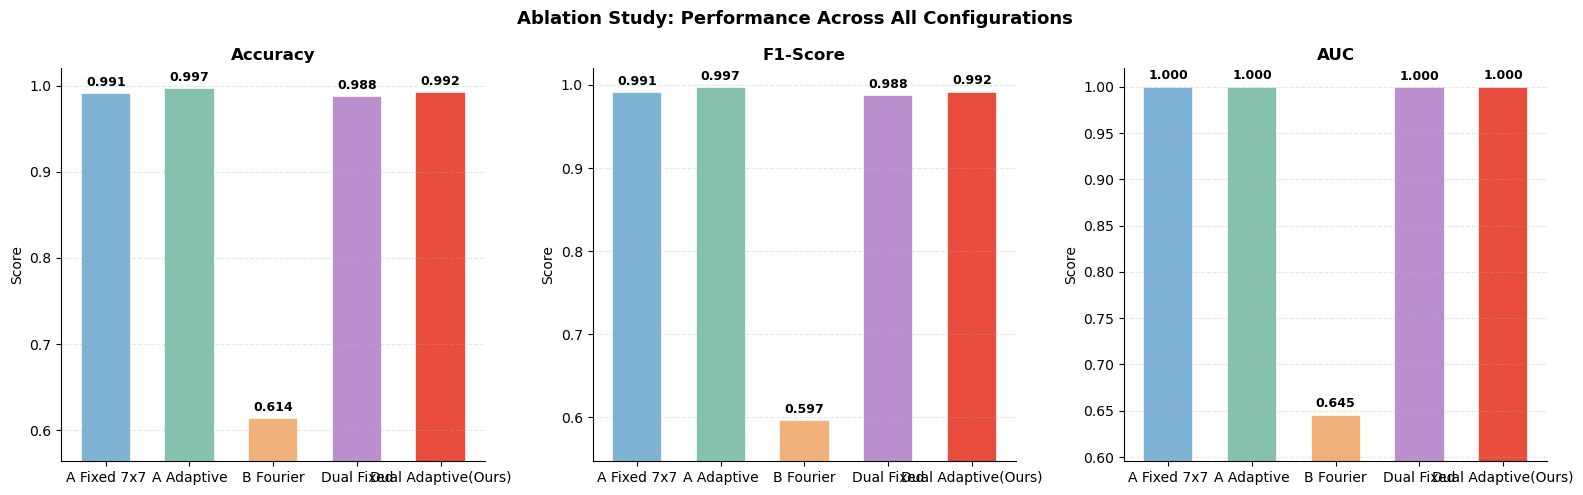

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Ablation Study: Performance Across All Configurations",
             fontsize=13, fontweight="bold")

names  = list(results.keys())
short  = ["A Fixed 7x7",
          "A Adaptive",
          "B Fourier",
          "Dual Fixed",
          "Dual Adaptive(Ours)"]
colors = ["#7FB3D3", "#85C1AE", "#F0B27A", "#BB8FCE", "#E74C3C"]

for ax, (mk, ml) in zip(axes, [("accuracy","Accuracy"),("f1","F1-Score"),("auc","AUC")]):
    values = [results[n][mk] for n in names]
    bars = ax.bar(short, values, color=colors, edgecolor="white", linewidth=1.2, width=0.6)
    ax.set_title(ml, fontsize=12, fontweight="bold")
    ax.set_ylim(max(0, min(values) - 0.05), 1.02)
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. ROC Curves - All Configurations

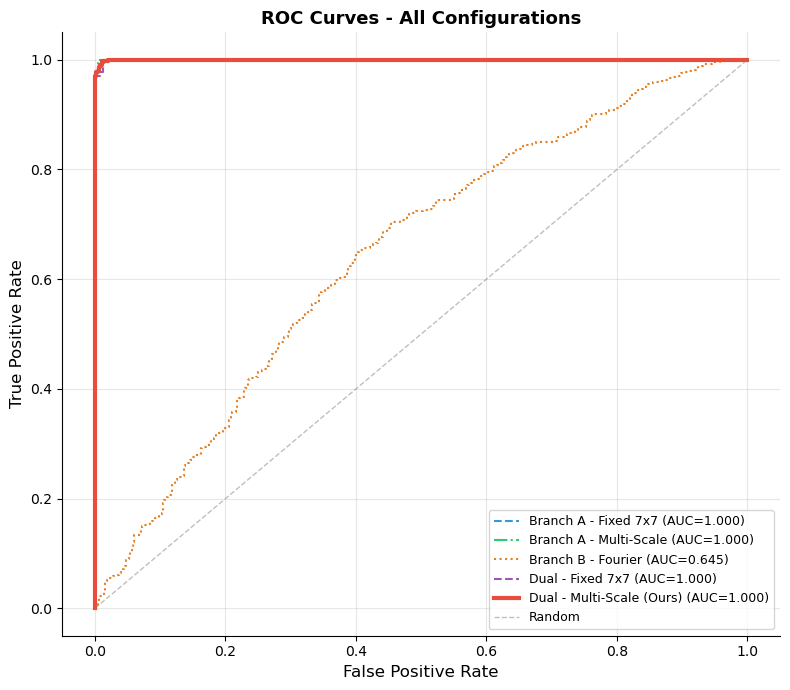

In [30]:
fig, ax = plt.subplots(figsize=(8, 7))
palette    = ["#3498DB", "#2ECC71", "#E67E22", "#9B59B6", "#E74C3C"]
lwidths    = [1.5, 1.5, 1.5, 1.5, 3.0]
linestyles = ["--", "-.", ":", "--", "-"]

for (name, res), color, lw, ls in zip(results.items(), palette, lwidths, linestyles):
    ax.plot(res["fpr"], res["tpr"], color=color, lw=lw, ls=ls,
            label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0,1],[0,1], color="gray", lw=1, ls="--", alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves - All Configurations", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Confusion Matrix - Best Model

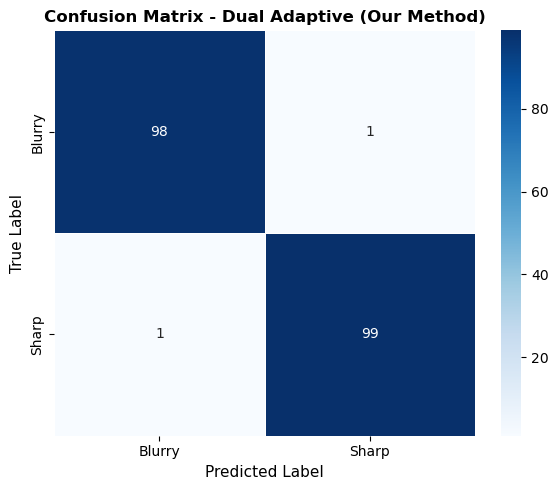

True Positives  (Sharp correctly predicted):  99
True Negatives  (Blurry correctly predicted): 98
False Positives (Blurry predicted as Sharp):  1
False Negatives (Sharp predicted as Blurry):  1


In [32]:
best_key = "Dual - Adaptive (Ours)"
if best_key in results:
    cm = results[best_key]["cm"]
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Blurry","Sharp"],
                yticklabels=["Blurry","Sharp"],
                linewidths=0.5, ax=ax)
    ax.set_title("Confusion Matrix - Dual Adaptive (Our Method)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"True Positives  (Sharp correctly predicted):  {cm[1][1]}")
    print(f"True Negatives  (Blurry correctly predicted): {cm[0][0]}")
    print(f"False Positives (Blurry predicted as Sharp):  {cm[0][1]}")
    print(f"False Negatives (Sharp predicted as Blurry):  {cm[1][0]}")

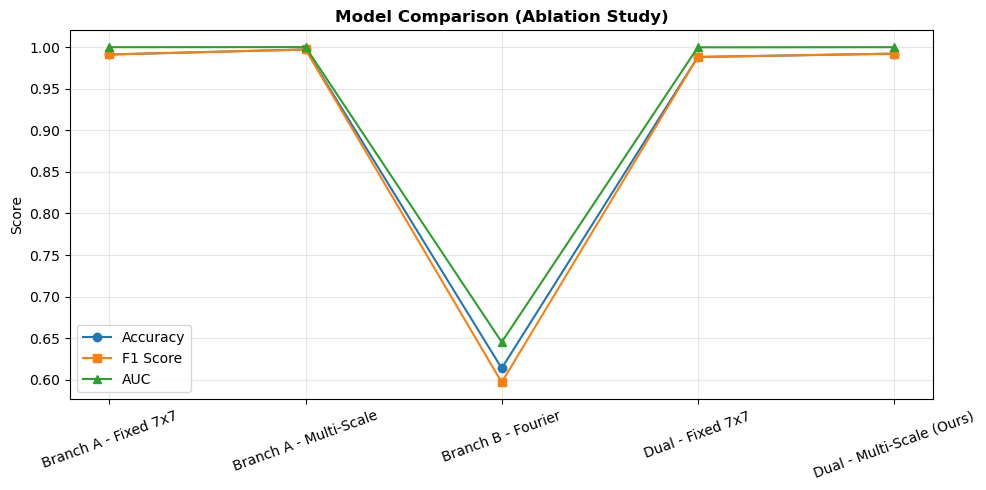

In [19]:
import matplotlib.pyplot as plt

# Extract results
model_names = []
accuracy = []
f1_scores = []
auc_scores = []

for name, res in results.items():
    model_names.append(name)
    accuracy.append(res["accuracy"])
    f1_scores.append(res["f1"])
    auc_scores.append(res["auc"])

# Plot
x = range(len(model_names))

plt.figure(figsize=(10, 5))

plt.plot(x, accuracy, marker='o', label="Accuracy")
plt.plot(x, f1_scores, marker='s', label="F1 Score")
plt.plot(x, auc_scores, marker='^', label="AUC")

plt.xticks(x, model_names, rotation=20)
plt.ylabel("Score")
plt.title("Model Comparison (Ablation Study)", fontsize=12, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Single Image Prediction

In [ ]:
# ============================================================
# 11. SINGLE IMAGE PREDICTION (DEMO)
# ============================================================
# This function allows testing on a single image.
#
# Steps:
# - Extract features
# - Load trained model
# - Predict label
# - Show:
#     • Input image
#     • Fourier spectrum
#     • Prediction + confidence
#
# Useful for real-time demonstration.
# ============================================================

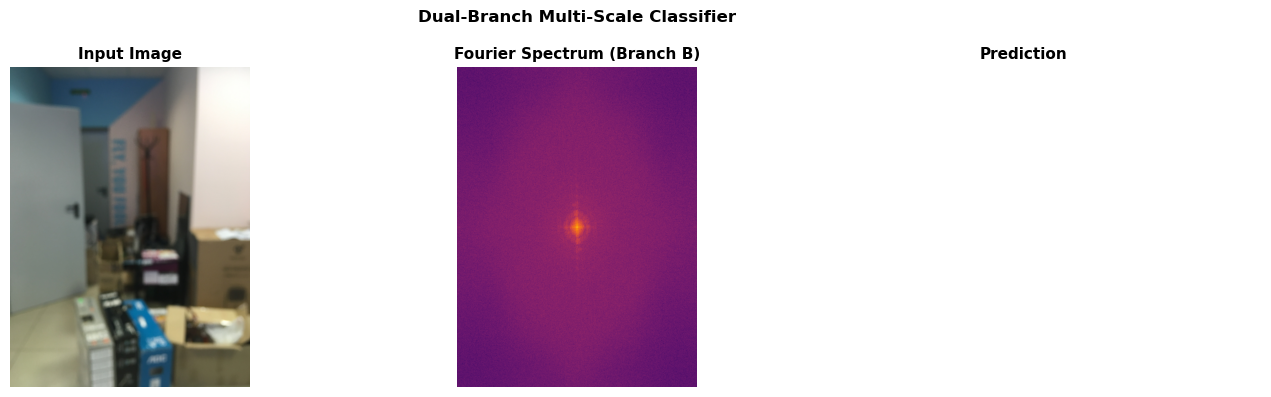

Prediction : Blurry (99.9% confidence)
Features   : 1096 (multi-scale)


In [27]:
def predict_single_image(image_path):
    if not os.path.exists(image_path):
        print(f"File not found: {image_path}")
        return

    img = cv2.imread(image_path)
    if img is None:
        print("Could not read image.")
        return

    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    H, W = gray.shape

    # --- Fourier visualization (Branch B) ---
    hann_2d  = np.outer(np.hanning(H), np.hanning(W))
    spectrum = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(gray.astype(np.float32) * hann_2d))))
    spec_vis = ((spectrum - spectrum.min()) /
                (spectrum.max() - spectrum.min() + 1e-8) * 255).astype(np.uint8)

    # --- Load trained model ---
    best_key = "Dual - Multi-Scale (Ours)"
    if best_key not in results:
        print("Model not trained yet.")
        return

    m = results[best_key]["model"]
    s = results[best_key]["scaler"]

    features = extract_dual_branch_features(image_path)
    if features is None:
        print("Feature extraction failed.")
        return

    pred  = m.predict(s.transform([features]))[0]
    prob  = m.predict_proba(s.transform([features]))[0]

    label = "Sharp" if pred == 1 else "Blurry"
    conf  = prob[1] if pred == 1 else prob[0]

    # --- Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Image
    axes[0].imshow(img_rgb)
    axes[0].set_title("Input Image", fontsize=11, fontweight="bold")
    axes[0].axis("off")

    # Fourier
    axes[1].imshow(spec_vis, cmap="inferno")
    axes[1].set_title("Fourier Spectrum (Branch B)", fontsize=11, fontweight="bold")
    axes[1].axis("off")

    # Prediction
    color = "#2ECC71" if label == "Sharp" else "#E74C3C"
    axes[2].set_facecolor(color)
    axes[2].text(0.5, 0.6, label, transform=axes[2].transAxes,
                 ha="center", fontsize=28, fontweight="bold", color="white")
    axes[2].text(0.5, 0.4, f"{conf:.1%} confidence",
                 transform=axes[2].transAxes, ha="center", fontsize=14, color="white")

    axes[2].text(0.5, 0.2,
                 "Multi-scale: 3x3 + 5x5 + 7x7\nFeatures: {}".format(len(features)),
                 transform=axes[2].transAxes, ha="center",
                 fontsize=10, color="white", alpha=0.8)

    axes[2].set_title("Prediction", fontsize=11, fontweight="bold")
    axes[2].axis("off")

    plt.suptitle("Dual-Branch Multi-Scale Classifier", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Prediction : {label} ({conf:.1%} confidence)")
    print(f"Features   : {len(features)} (multi-scale)")


# Run
predict_single_image("test.JPG")

## 14. Save Best Model

In [ ]:
# ============================================================
# 12. MODEL SAVING
# ============================================================
# The trained model and scaler are saved using joblib.
#
# This allows:
# - Reusing model without retraining
# - Faster deployment
# ============================================================

In [28]:
import joblib

best_key = "Dual - Multi-Scale (Ours)"
if best_key in results:
    joblib.dump(results[best_key]["model"],  "dual_branch_adaptive_model.pkl")
    joblib.dump(results[best_key]["scaler"], "dual_branch_adaptive_scaler.pkl")
    print("Saved: dual_branch_adaptive_model.pkl")
    print("Saved: dual_branch_adaptive_scaler.pkl")
    print()
    print("To load and use later:")
    print("  import joblib")
    print("  model  = joblib.load('dual_branch_adaptive_model.pkl')")
    print("  scaler = joblib.load('dual_branch_adaptive_scaler.pkl')")
    print("  feats  = extract_dual_branch_features('your_image.jpg')")
    print("  pred   = model.predict(scaler.transform([feats]))[0]")
    print("  label  = 'Sharp' if pred == 1 else 'Blurry'")

Saved: dual_branch_adaptive_model.pkl
Saved: dual_branch_adaptive_scaler.pkl

To load and use later:
  import joblib
  model  = joblib.load('dual_branch_adaptive_model.pkl')
  scaler = joblib.load('dual_branch_adaptive_scaler.pkl')
  feats  = extract_dual_branch_features('your_image.jpg')
  pred   = model.predict(scaler.transform([feats]))[0]
  label  = 'Sharp' if pred == 1 else 'Blurry'
